# GEQDSK and P-file Reader Example

Demonstrates the `eqdsk` module for reading standard GEQDSK (g-file)
equilibrium files and Osborne p-files (kinetic profiles) without
OMFIT or external dependencies.

**What this notebook covers:**
1. Reading a g-file and inspecting scalar quantities
2. Plotting the 2-D poloidal flux and boundary
3. Inspecting 1-D profiles (pressure, safety factor, F)
4. Computing flux-surface-averaged quantities
5. Reading a p-file and plotting kinetic profiles
6. COCOS conversion and g-file round-trip (read/write/re-read)

In [ ]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Add OFT python path (adjust if needed)
tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))

from OpenFUSIONToolkit.TokaMaker.eqdsk import (
    read_geqdsk, write_geqdsk, GEQDSKEquilibrium,
    read_pfile, PFile,
)

## 1. Read a GEQDSK file

In [2]:
eq = read_geqdsk('TkMkr_D3Dlike_Hmode_BSamp=1.0.geqdsk')

print(f'R_mag  = {eq.R_mag:.4f} m')
print(f'Z_mag  = {eq.Z_mag:.4f} m')
print(f'Ip     = {eq.Ip/1e6:.4f} MA')
print(f'B0     = {eq.B_center:.4f} T')
print(f'R0     = {eq.R_center:.4f} m')
print(f'psi_ax = {eq.psi_axis:.6f} Wb')
print(f'psi_bd = {eq.psi_boundary:.6f} Wb')
print(f'COCOS  = {eq.cocos}')
print(f'Grid   = {len(eq.R_grid)} x {len(eq.Z_grid)}')

R_mag  = 1.7438 m
Z_mag  = -0.0053 m
Ip     = 1.2000 MA
B0     = 2.0243 T
R0     = 1.6796 m
psi_ax = 0.348276 Wb
psi_bd = 0.044025 Wb
COCOS  = 1
Grid   = 257 x 257


### 1a. Discover what's available

Every `GEQDSKEquilibrium` object exposes two introspection helpers:

- **`eq.keys`** — a flat list of every accessible attribute name (scalars,
  raw 1-D profiles, 2-D grids, and lazily-computed flux-surface quantities).
- **`eq.describe()`** — prints a categorised summary with descriptions,
  units, and shapes. Pass `verbose=True` to also trigger the lazy
  flux-surface trace and reveal dict sub-keys (e.g. `geometry["kappa"]`).

Access any listed name as a normal attribute (`eq.q_profile`, `eq.li`,
`eq.geometry['kappa']`, ...).

In [3]:
# Get a flat list of every quantity the equilibrium object exposes
print('Available quantities (eq.keys):')
for name in eq.keys:
    print(f'  - {name}')

print()

# Print a categorised, human-readable summary.  By default, lazy FSA quantities
# are NOT computed so this is instant.  Pass verbose=True to trigger the
# flux-surface trace and see dict sub-keys and actual shapes.
eq.describe()


Available quantities (eq.keys):
  - Ip
  - R_mag
  - Z_mag
  - R_center
  - B_center
  - psi_axis
  - psi_boundary
  - cocos
  - fpol
  - pres
  - pprime
  - ffprim
  - qpsi
  - rhovn
  - psi_N
  - boundary_R
  - boundary_Z
  - limiter_R
  - limiter_Z
  - R_grid
  - Z_grid
  - psi_RZ
  - psi_N_RZ
  - q_profile
  - j_tor_averaged
  - j_tor_averaged_direct
  - j_tor_averaged_numerical
  - j_tor_over_R
  - geometry
  - averages
  - midplane
  - li
  - betas
  - contours

GEQDSKEquilibrium (COCOS 1, NW=257, NH=257, nlevels=257)

Global scalars
--------------
  Ip                             Plasma current                                   [A]
                                   -> 1.20004e+06
  R_mag                          Magnetic axis R                                  [m]
                                   -> 1.74382
  Z_mag                          Magnetic axis Z                                  [m]
                                   -> -0.00531558
  R_center                       Re

## 2. Plot 2-D poloidal flux and boundary

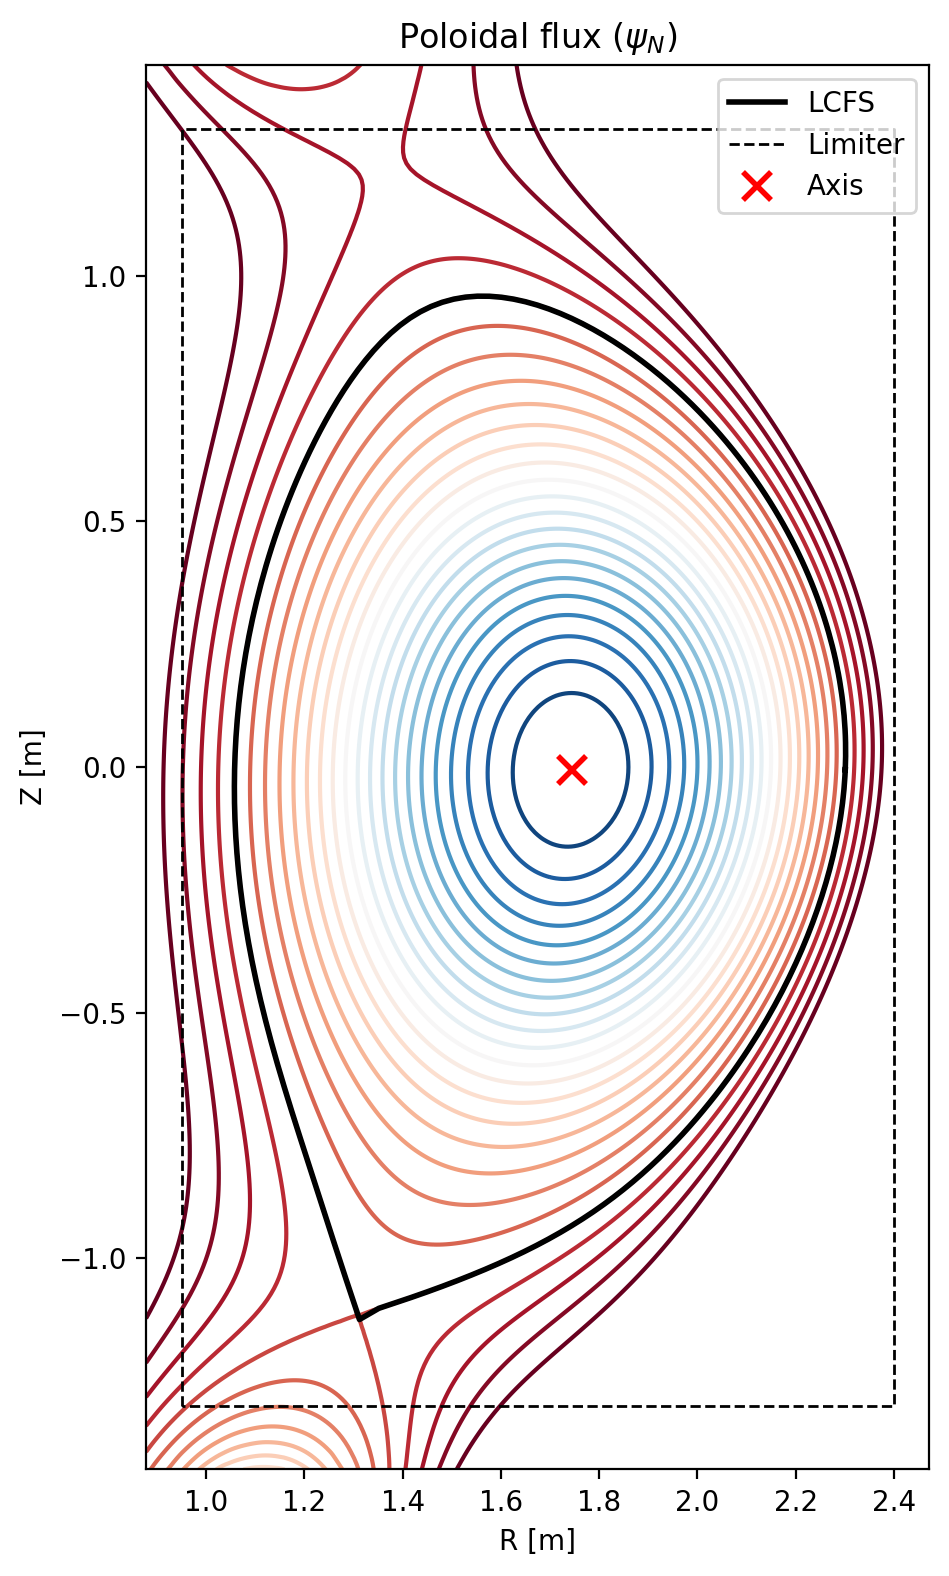

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(5, 8))

# Normalised psi contours
cs = ax.contour(eq.R_grid, eq.Z_grid, eq.psi_N_RZ,
                levels=np.linspace(0, 1.2, 25), cmap='RdBu_r')
#ax.clabel(cs, levels=[0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=8, fmt='%.1f')

# Boundary (LCFS)
ax.plot(eq.boundary_R, eq.boundary_Z, 'k-', lw=2, label='LCFS')

# Limiter
if len(eq.limiter_R) > 0:
    ax.plot(eq.limiter_R, eq.limiter_Z, 'k--', lw=1, label='Limiter')

# Magnetic axis
ax.plot(eq.R_mag, eq.Z_mag, 'rx', ms=10, mew=2, label='Axis')

ax.set_xlabel('R [m]')
ax.set_ylabel('Z [m]')
ax.set_title('Poloidal flux ($\\psi_N$)')
ax.set_aspect('equal')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 3. 1-D profiles from the g-file

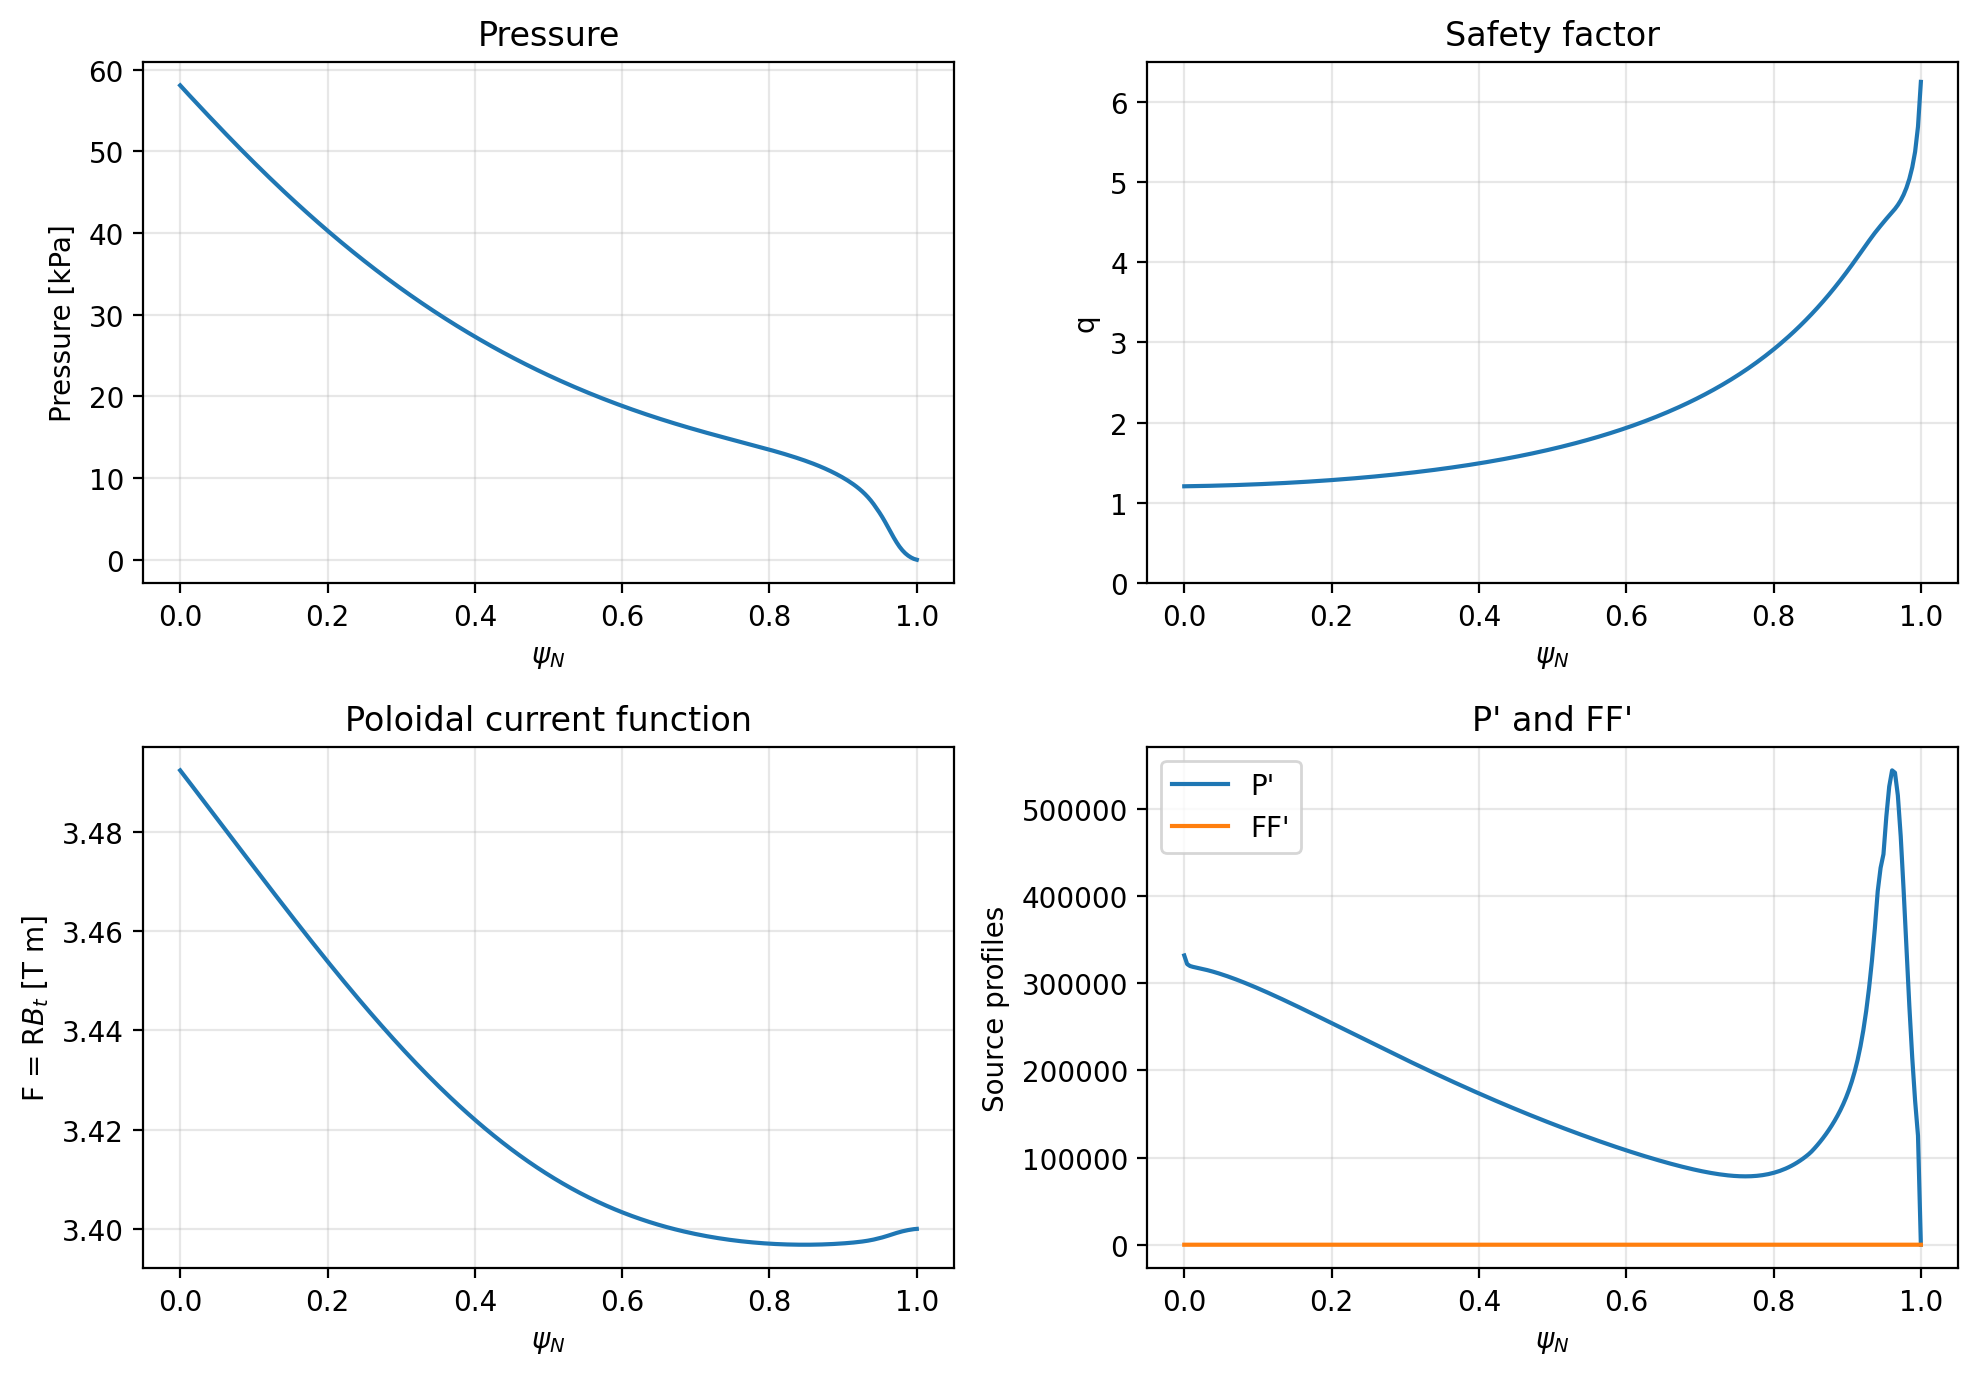

In [5]:
psi_N = eq.psi_N  # raw NW-long grid matching eq.fpol / eq.pres / eq.pprime / eq.ffprim / eq.qpsi

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].plot(psi_N, eq.pres / 1e3)
axes[0, 0].set_ylabel('Pressure [kPa]')
axes[0, 0].set_title('Pressure')

axes[0, 1].plot(psi_N, eq.qpsi)
axes[0, 1].set_ylabel('q')
axes[0, 1].set_title('Safety factor')
axes[0, 1].set_ylim(bottom=0)

axes[1, 0].plot(psi_N, eq.fpol)
axes[1, 0].set_ylabel('F = R$B_t$ [T m]')
axes[1, 0].set_title('Poloidal current function')

axes[1, 1].plot(psi_N, eq.pprime, label="P'")
axes[1, 1].plot(psi_N, eq.ffprim, label="FF'")
axes[1, 1].set_ylabel('Source profiles')
axes[1, 1].set_title("P' and FF'")
axes[1, 1].legend()

for ax in axes.flat:
    ax.set_xlabel('$\\psi_N$')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Flux-surface-averaged quantities

The `GEQDSKEquilibrium` class lazily traces flux-surface contours
and computes averaged quantities on first access.

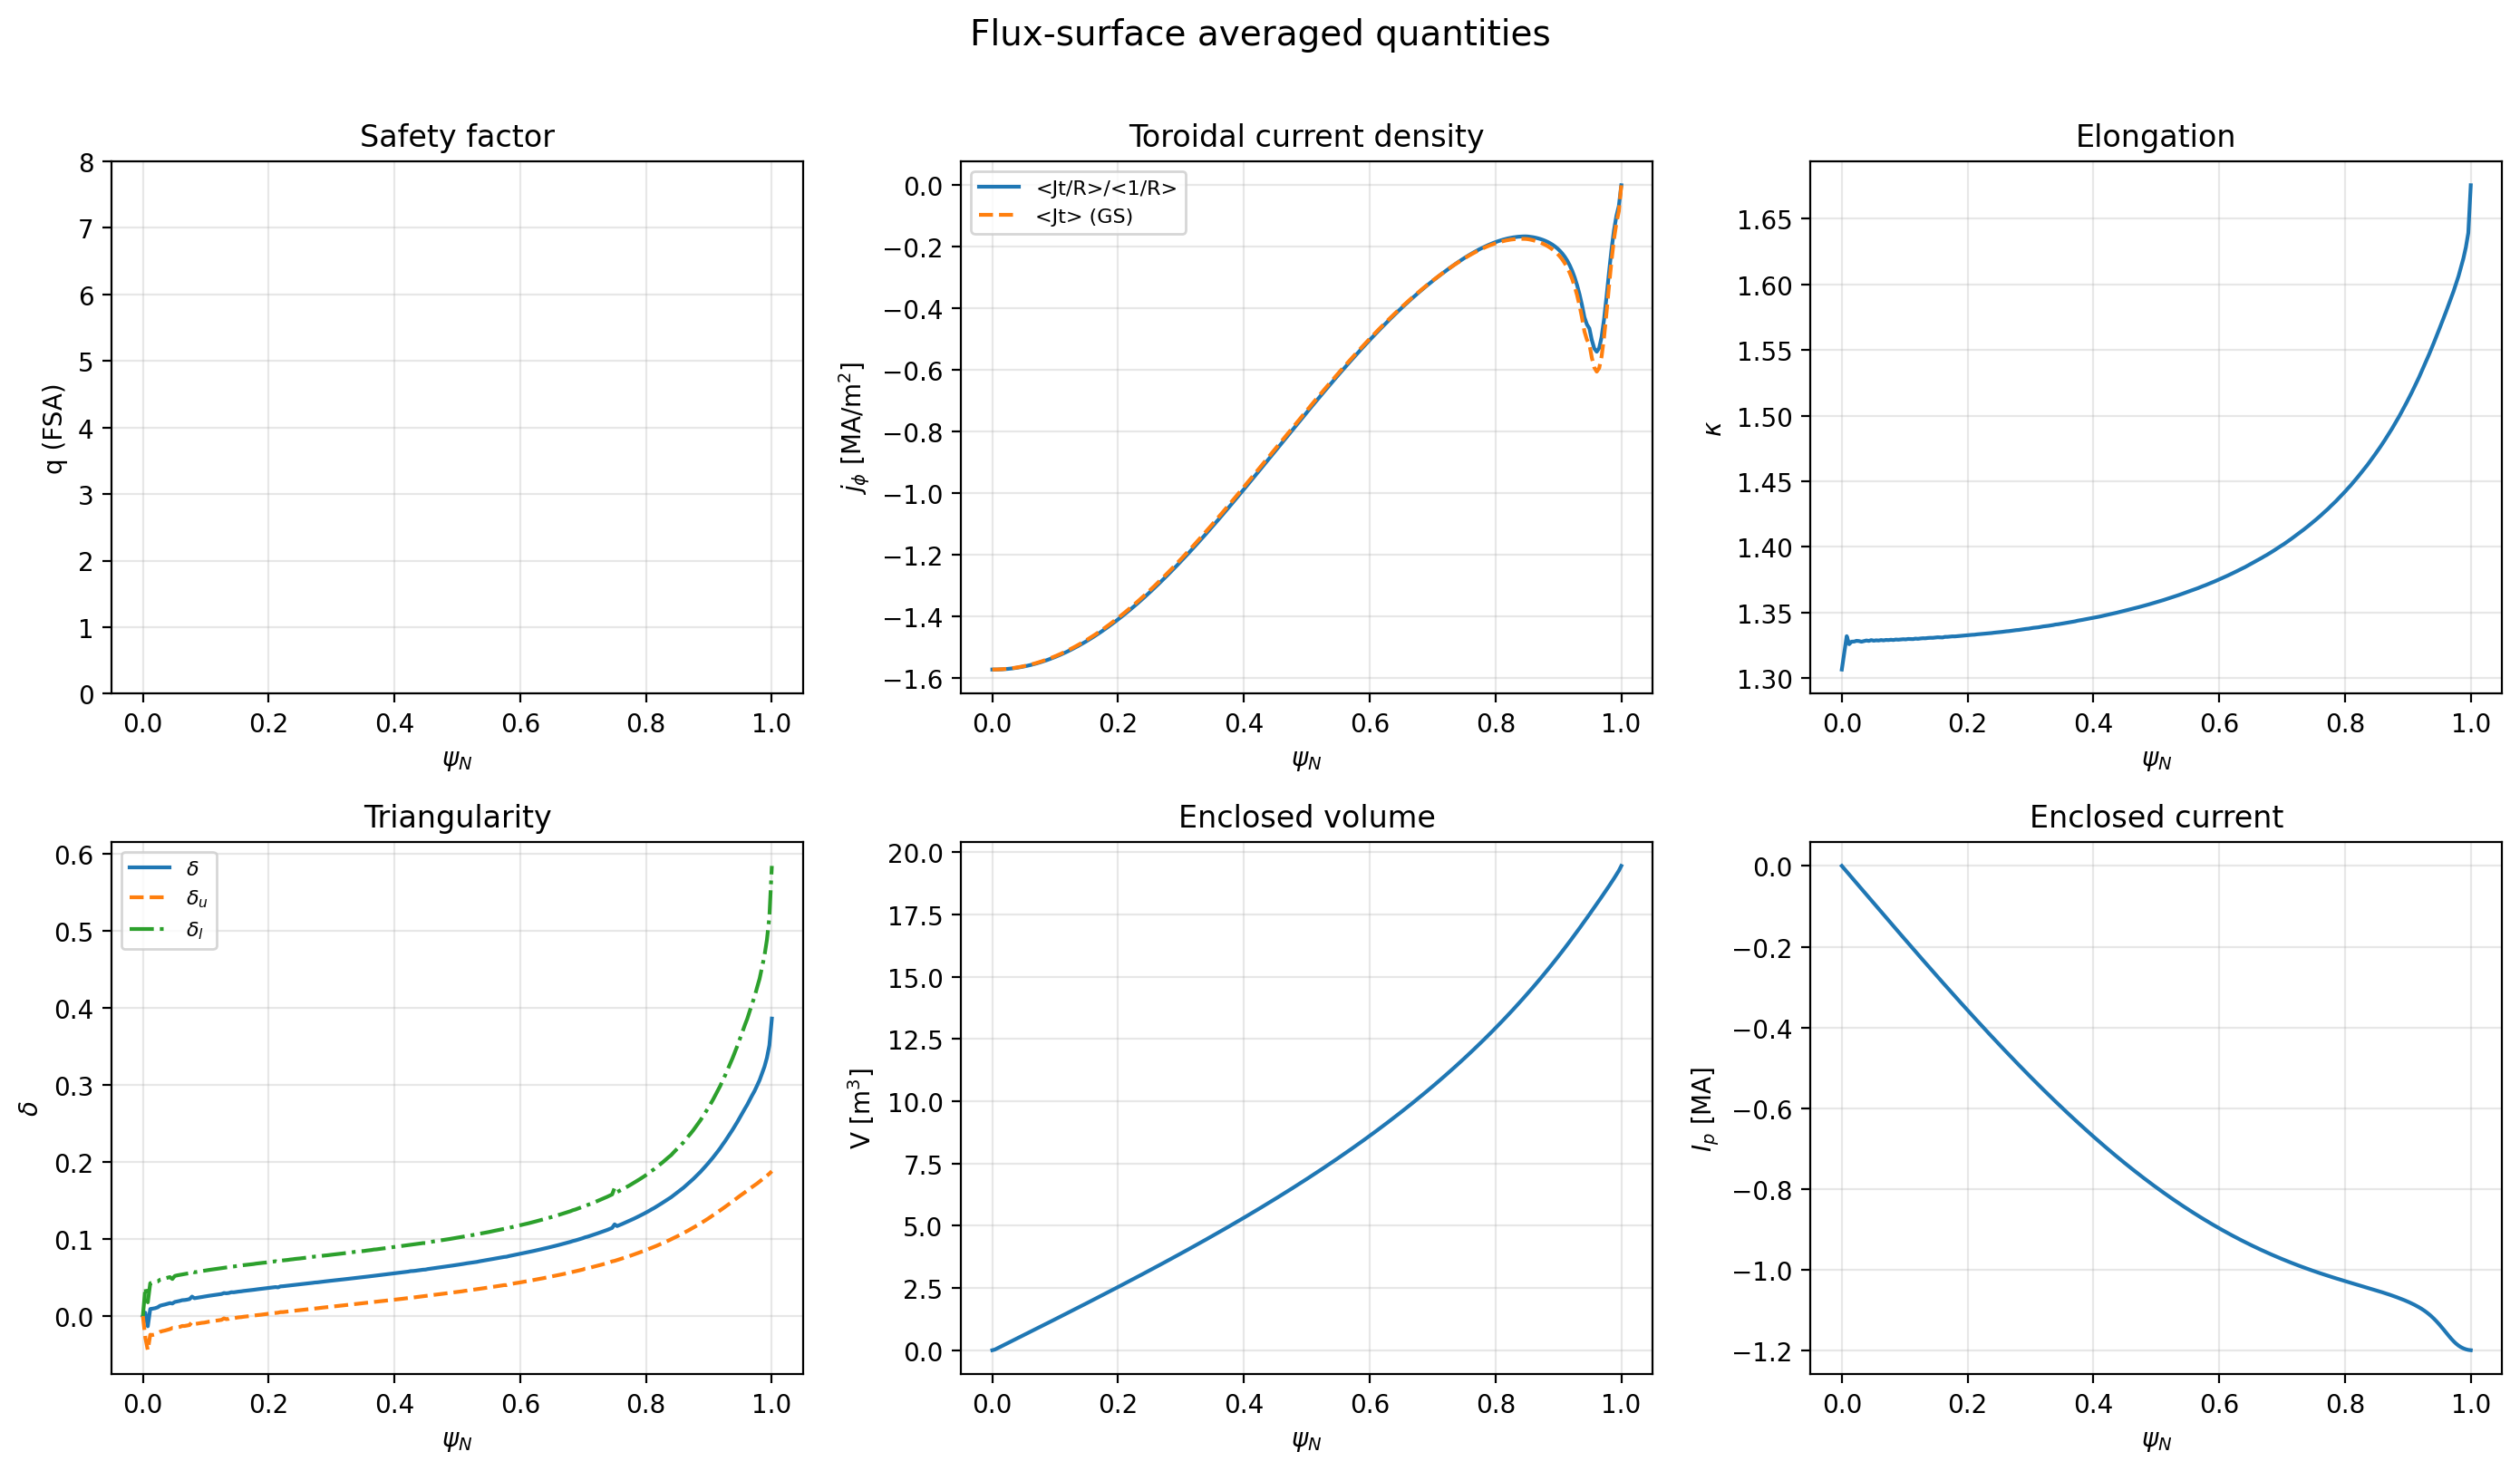

li(1) = 1.0660
li(3) = 0.8977
beta_t = 0.0130
beta_n = 1.3632
beta_p = 0.6430


In [6]:
psi_N_eq = eq.psi_N_levels  # FSA grid (length nlevels); eq.psi_N is the raw NW-long grid
geo = eq.geometry
avg = eq.averages

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Safety factor (from FSA)
axes[0, 0].plot(psi_N_eq, eq.q_profile)
axes[0, 0].set_ylabel('q (FSA)')
axes[0, 0].set_title('Safety factor')
axes[0, 0].set_ylim(0, 8)

# <Jt> current density
axes[0, 1].plot(psi_N_eq, eq.j_tor_averaged / 1e6, label='<Jt/R>/<1/R>')
axes[0, 1].plot(psi_N_eq, eq.j_tor_averaged_direct / 1e6, '--', label='<Jt> (GS)')
axes[0, 1].set_ylabel('$j_\\phi$ [MA/m$^2$]')
axes[0, 1].set_title('Toroidal current density')
axes[0, 1].legend(fontsize=8)

# Elongation
axes[0, 2].plot(psi_N_eq, geo['kappa'])
axes[0, 2].set_ylabel('$\\kappa$')
axes[0, 2].set_title('Elongation')

# Triangularity
axes[1, 0].plot(psi_N_eq, geo['delta'], label='$\\delta$')
axes[1, 0].plot(psi_N_eq, geo['delu'], '--', label='$\\delta_u$')
axes[1, 0].plot(psi_N_eq, geo['dell'], '-.', label='$\\delta_l$')
axes[1, 0].set_ylabel('$\\delta$')
axes[1, 0].set_title('Triangularity')
axes[1, 0].legend(fontsize=8)

# Volume
axes[1, 1].plot(psi_N_eq, geo['vol'])
axes[1, 1].set_ylabel('V [m$^3$]')
axes[1, 1].set_title('Enclosed volume')

# Enclosed current
axes[1, 2].plot(psi_N_eq, avg['ip'] / 1e6)
axes[1, 2].set_ylabel('$I_p$ [MA]')
axes[1, 2].set_title('Enclosed current')

for ax in axes.flat:
    ax.set_xlabel('$\\psi_N$')
    ax.grid(True, alpha=0.3)

plt.suptitle('Flux-surface averaged quantities', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Print global quantities
print(f"li(1) = {eq.li['li(1)']:.4f}")
print(f"li(3) = {eq.li['li(3)']:.4f}")
for k, v in eq.betas.items():
    print(f"{k} = {v:.4f}")

## 5. Plot traced flux-surface contours

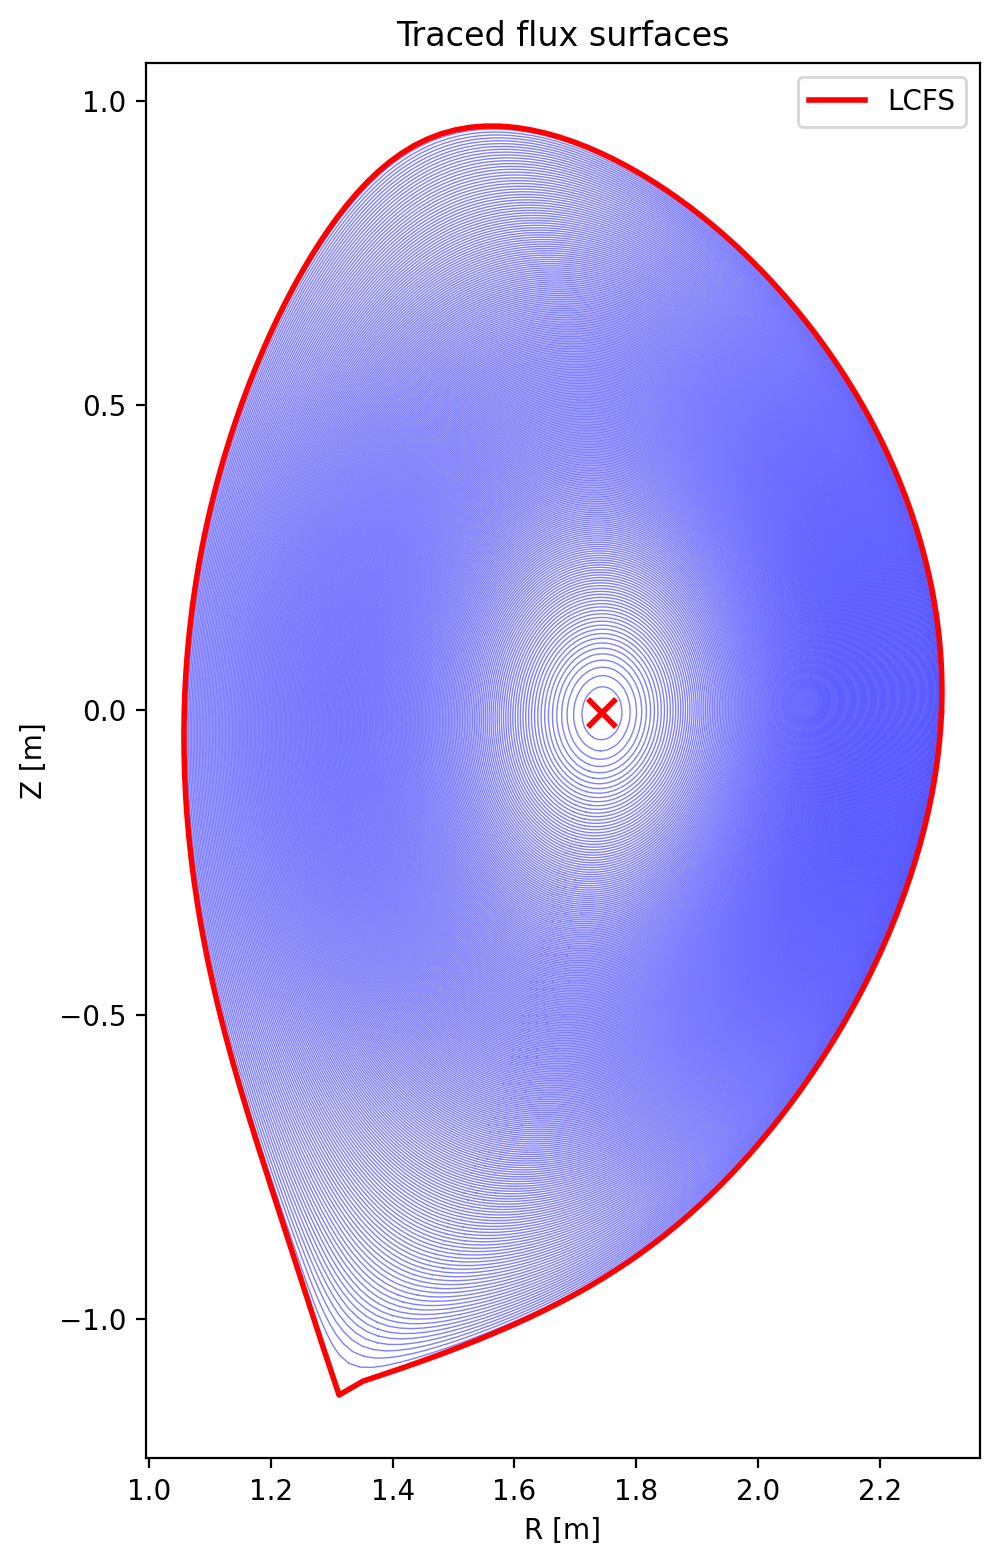

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(5, 8))

for k, contour in enumerate(eq.contours):
    if contour.shape[0] > 1:
        ax.plot(contour[:, 0], contour[:, 1], 'b-', lw=0.5, alpha=0.5)

ax.plot(eq.boundary_R, eq.boundary_Z, 'r-', lw=2, label='LCFS')
ax.plot(eq.R_mag, eq.Z_mag, 'rx', ms=10, mew=2)

ax.set_xlabel('R [m]')
ax.set_ylabel('Z [m]')
ax.set_title('Traced flux surfaces')
ax.set_aspect('equal')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Read a p-file (kinetic profiles)

In [8]:
pf = read_pfile('TkMkr_D3Dlike_Hmode_BSamp=1.0.peqdsk')
print(pf)
print(f'Available profiles: {pf.keys}')

PFile(14 profiles: ne, te, ni, ti, nz1, ptot...)
Available profiles: ['ne', 'te', 'ni', 'ti', 'N Z A', 'nz1', 'ptot', 'omgpp', 'ommpp', 'omepp', 'omgeb', 'ommvb', 'omevb', 'er', 'omghb']


### 6a. Discover what's in the p-file

The `PFile` object has the same introspection pattern as the equilibrium:

- **`pf.keys`** — list of profile names present in the file (plus the
  `"N Z A"` ion-species block if present).
- **`pf.describe()`** — categorised summary grouped by physics
  (kinetic profiles, rotation / Er, impurity / beam), with per-profile
  units, length, value range, and a reminder of which quantities can be
  computed via helper methods (`compute_pressure`, `compute_quasineutrality`,
  `compute_zeff`, rotation decompositions).

In [9]:
# Categorised summary of all profiles, grouped by physics (kinetic, rotation,
# impurity, ...).  Also lists the ion-species block and the physics helpers
# you can call to compute derived profiles (pressure, Zeff, rotations, ...).
pf.describe()


PFile (15 entries)

Kinetic profiles
----------------
  ne         Electron density                                 [10^20/m^3]
               -> len=514, range=[0.07984, 0.55]
  te         Electron temperature                             [KeV]
               -> len=514, range=[0.06425, 2.5]
  ni         Ion density                                      [10^20/m^3]
               -> len=514, range=[0.06508, 0.45]
  ti         Ion temperature                                  [KeV]
               -> len=514, range=[0.2881, 5]
  ptot       Total pressure                                   [KPa]
               -> len=514, range=[0.3939, 59.41]

Rotation / Er
-------------
  omgpp      Diamagnetic term in the ExB rotation frequency   [kRad/s]
               -> len=514, range=[-13.02, -1.708]
  omgeb      ExB rotation frequency                           [kRad/s]
               -> len=514, range=[-13.02, -1.708]
  er         Radial electric field from force balance         [kV/m]
              

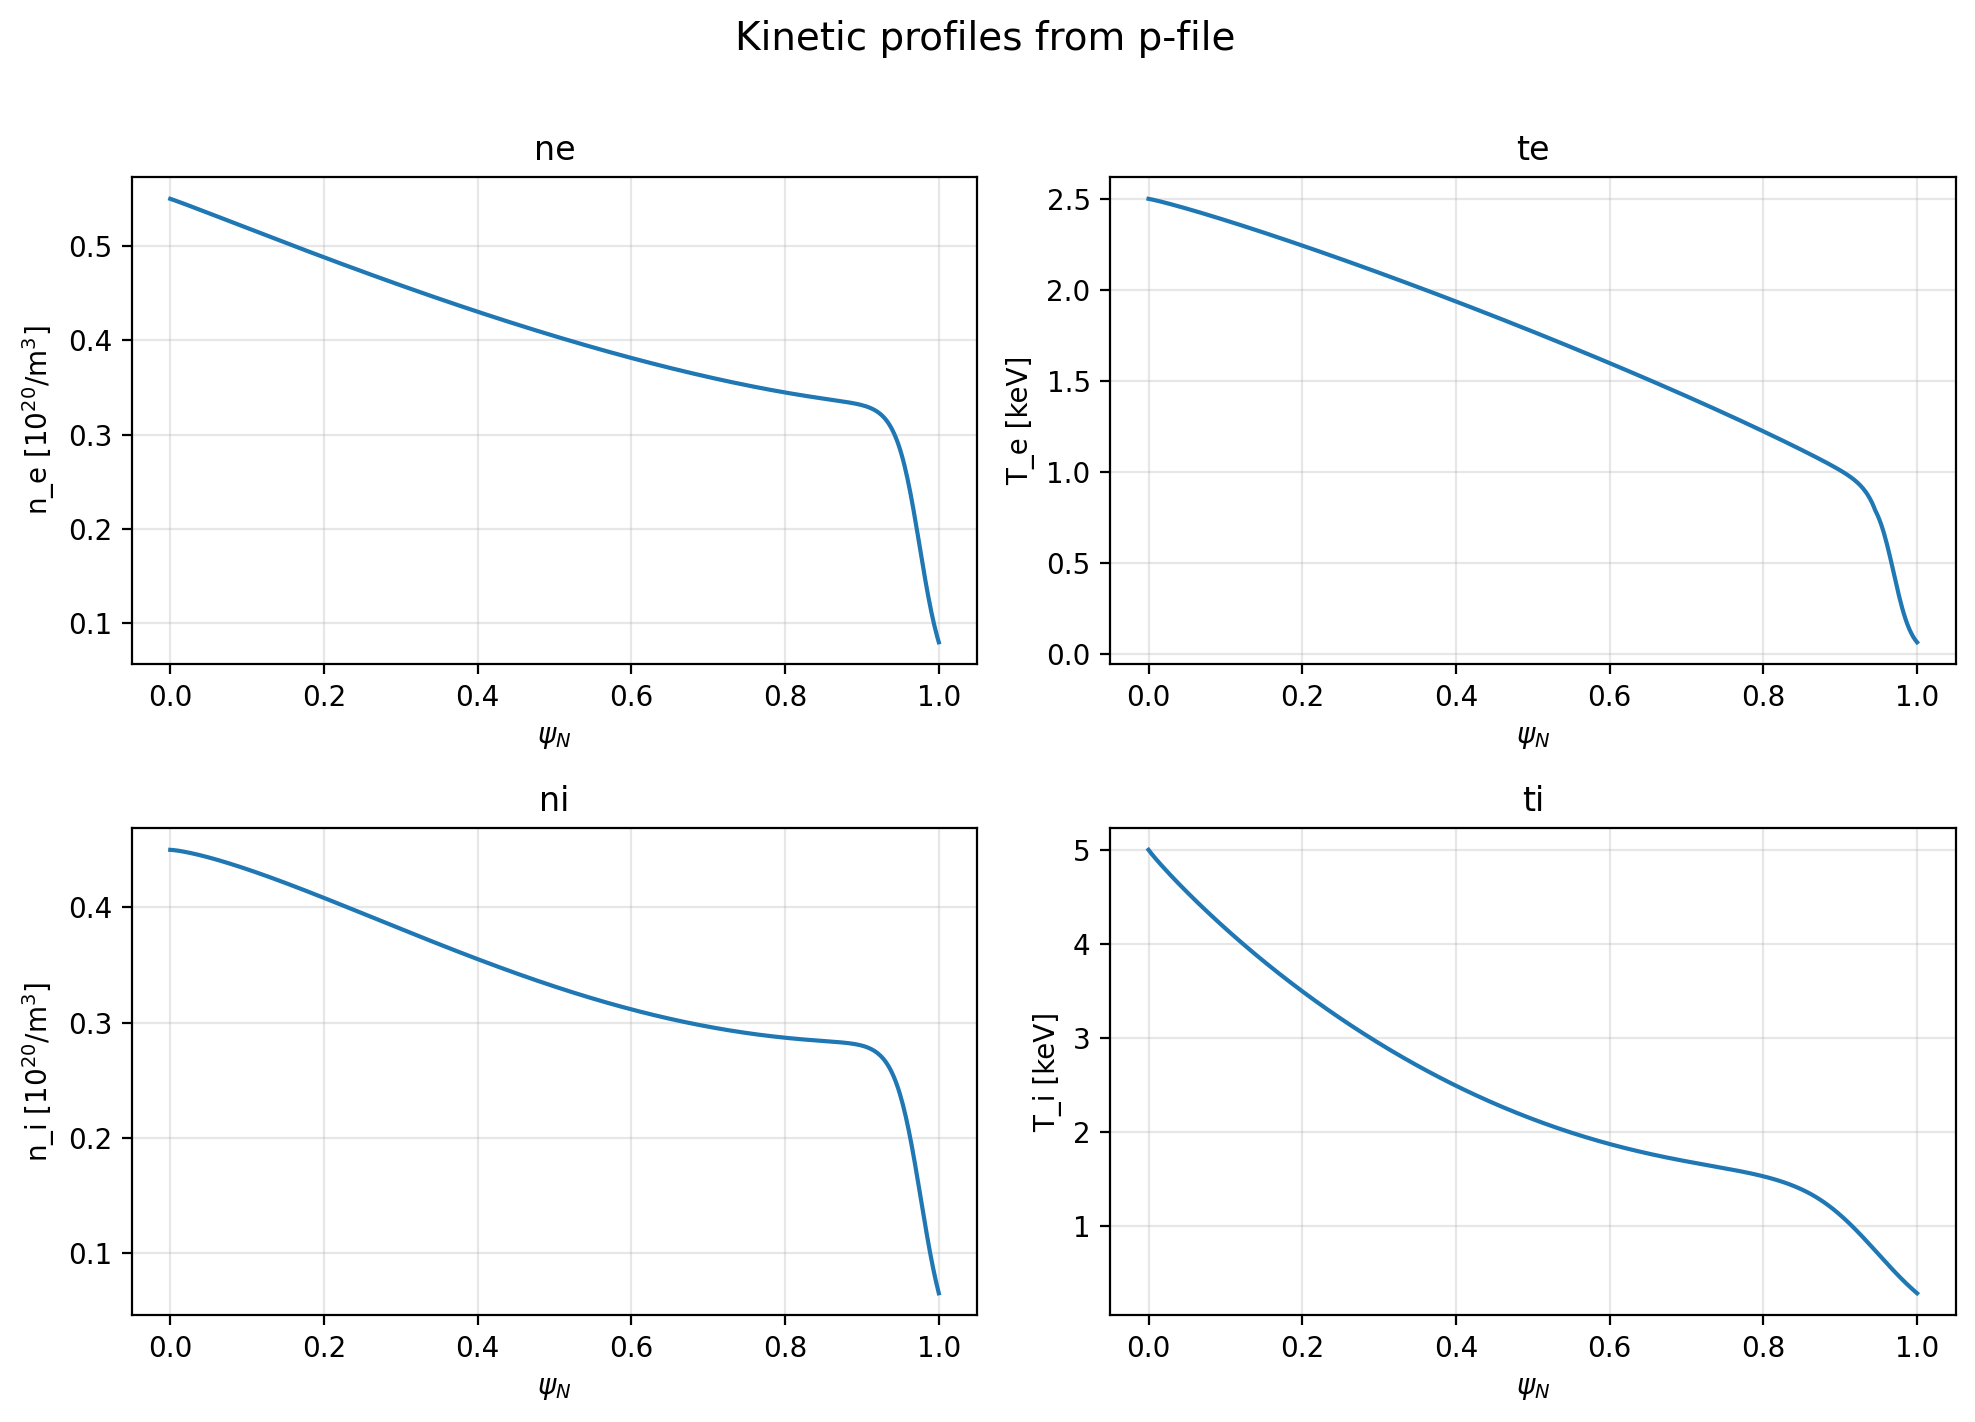

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

profiles = [
    ('ne', 'n_e [10$^{20}$/m$^3$]'),
    ('te', 'T_e [keV]'),
    ('ni', 'n_i [10$^{20}$/m$^3$]'),
    ('ti', 'T_i [keV]'),
]

for ax, (key, ylabel) in zip(axes.flat, profiles):
    psin = pf.psinorm_for(key)
    data = pf._get_data(key)
    if psin is not None and data is not None:
        ax.plot(psin, data, label=key)
        ax.set_ylabel(ylabel)
        ax.set_title(key)
    ax.set_xlabel('$\\psi_N$')
    ax.grid(True, alpha=0.3)

plt.suptitle('Kinetic profiles from p-file', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. P-file physics: pressure and Zeff

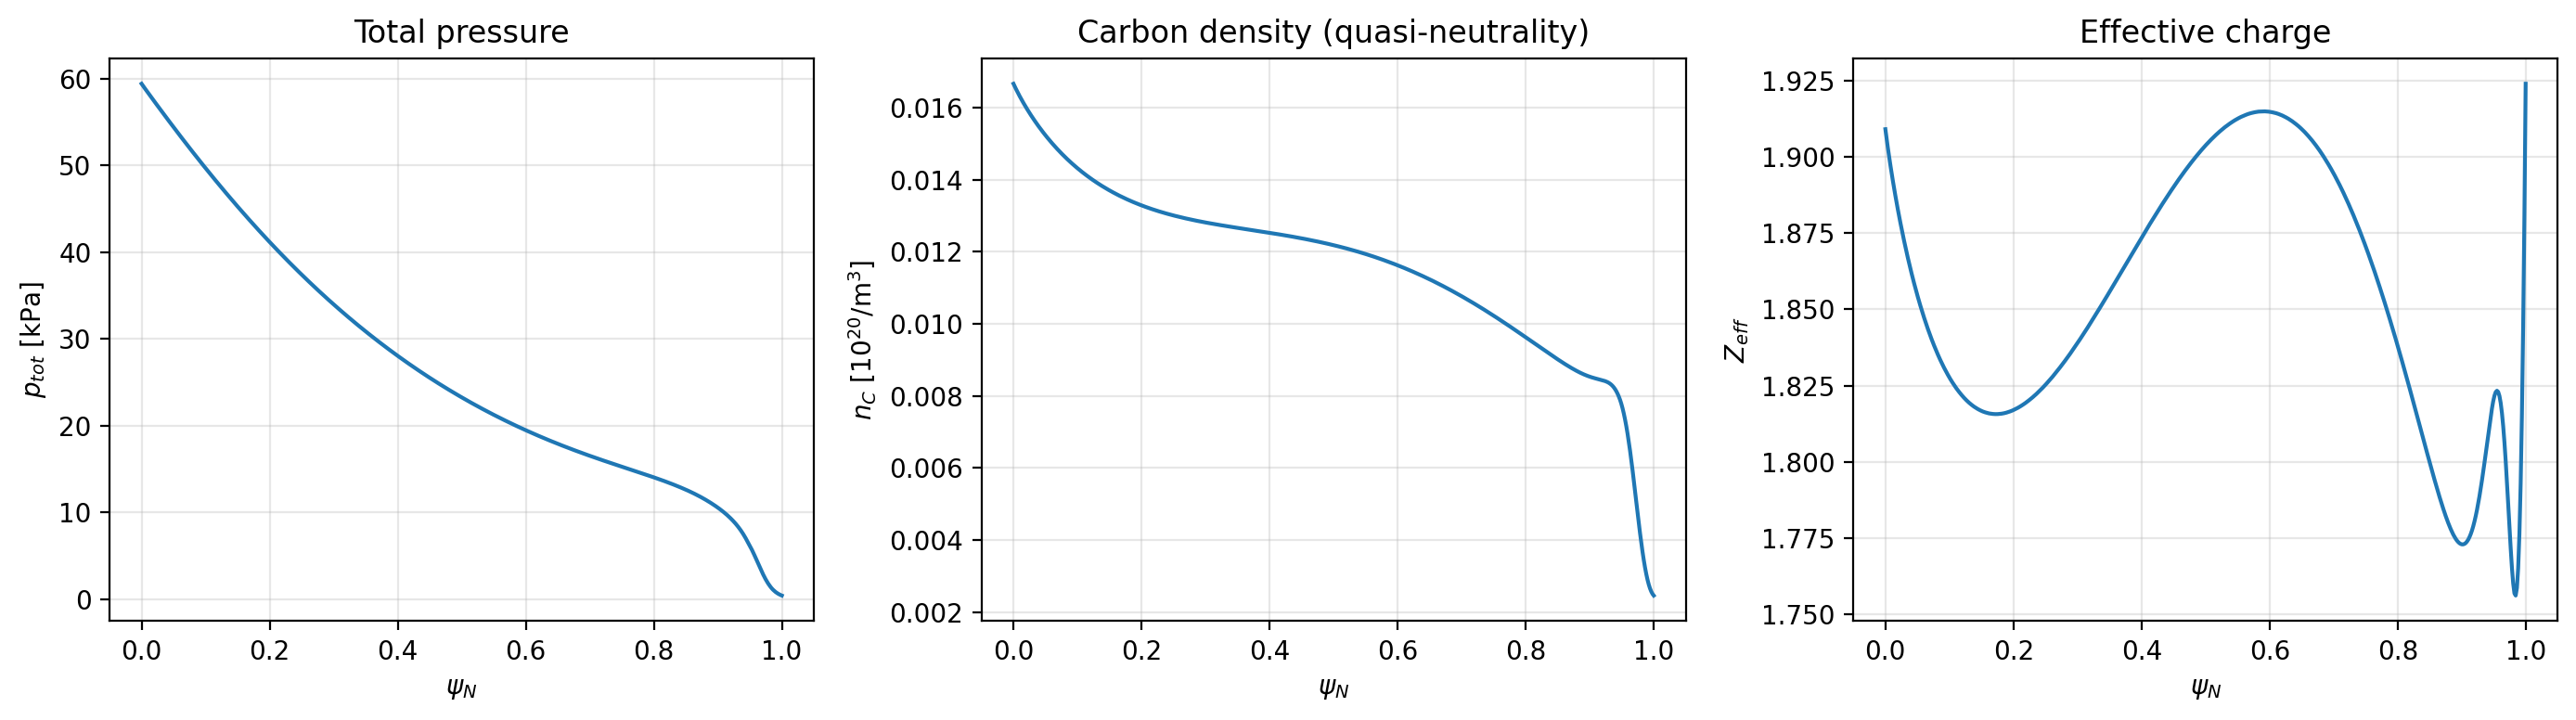

In [11]:
# Set ion species (Carbon impurity + D main + D beam)
pf.set_ion_species(N=[6, 1, 1], Z=[6, 1, 1], A=[12, 2, 2])

# Compute impurity density from quasi-neutrality
pf.compute_quasineutrality()

# Compute total pressure
pf.compute_pressure()

# Compute Zeff
psin_zeff, zeff = pf.compute_zeff()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(pf.psinorm_for('ptot'), pf.ptot)
axes[0].set_ylabel('$p_{tot}$ [kPa]')
axes[0].set_title('Total pressure')

axes[1].plot(pf.psinorm_for('nz1'), pf._get_data('nz1'))
axes[1].set_ylabel('$n_{C}$ [10$^{20}$/m$^3$]')
axes[1].set_title('Carbon density (quasi-neutrality)')

axes[2].plot(psin_zeff, zeff)
axes[2].set_ylabel('$Z_{eff}$')
axes[2].set_title('Effective charge')

for ax in axes:
    ax.set_xlabel('$\\psi_N$')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. COCOS conversion and g-file round-trip

In [12]:
# Convert COCOS 1 -> COCOS 11 (adds 2*pi factor to psi)
eq11 = eq.cocosify(11, copy=True)
print(f'Original COCOS={eq.cocos}:  psi_axis = {eq.psi_axis:.6f}')
print(f'COCOS 11:                   psi_axis = {eq11.psi_axis:.6f}')
print(f'Ratio = {eq11.psi_axis / eq.psi_axis:.6f}  (expect 2*pi = {2*np.pi:.6f})')

Original COCOS=1:  psi_axis = 0.348276
COCOS 11:                   psi_axis = 2.188282
Ratio = 6.283185  (expect 2*pi = 6.283185)


In [13]:
import tempfile

# Write and re-read to verify round-trip fidelity
with tempfile.NamedTemporaryFile(suffix='.geqdsk', delete=False) as tmp:
    tmpfile = tmp.name

eq.save(tmpfile)
eq_rt = read_geqdsk(tmpfile)
os.remove(tmpfile)

# Compare key quantities
print(f'Ip:       {eq.Ip:.2f}  ->  {eq_rt.Ip:.2f}  (err={abs(eq_rt.Ip-eq.Ip):.2e})')
print(f'psi_axis: {eq.psi_axis:.8f}  ->  {eq_rt.psi_axis:.8f}')
print(f'psi_bdy:  {eq.psi_boundary:.8f}  ->  {eq_rt.psi_boundary:.8f}')
print(f'PSIRZ max err: {np.max(np.abs(eq.psi_RZ - eq_rt.psi_RZ)):.2e}')
print(f'FPOL max err:  {np.max(np.abs(eq.fpol - eq_rt.fpol)):.2e}')
print(f'PRES max err:  {np.max(np.abs(eq.pres - eq_rt.pres)):.2e}')
print(f'QPSI max err:  {np.max(np.abs(eq.qpsi - eq_rt.qpsi)):.2e}')
print('\nRound-trip OK!' if np.max(np.abs(eq.psi_RZ - eq_rt.psi_RZ)) < 1e-6 else '\nRound-trip FAILED')

Ip:       1200039.50  ->  1200039.50  (err=0.00e+00)
psi_axis: 0.34827584  ->  0.34827584
psi_bdy:  0.04402488  ->  0.04402488
PSIRZ max err: 0.00e+00
FPOL max err:  0.00e+00
PRES max err:  0.00e+00
QPSI max err:  0.00e+00

Round-trip OK!
